# Workbook 02: Exploring word embeddings

В цій лабораторній ми детальніше розберемося з векторним представленням слів (word embeddings), а саме:

- Завантажимо вектори GloVe
- Перевіримо цікаві властивості цих векторів

У вас буде кілька завдань. Відповіді на завдання відправляють функції `lab.checkpoint()` та `lab.answer()`.

Для початку, заповніть параметр `email` нижче:

In [1]:
!pip install --quiet --ignore-installed requests==2.32.4 https://static.lp-nlp.com/pypi/lpnlp-2025.12.14-py3-none-any.whl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 907.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.7/254.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 3.9 MB/s eta 0:00:00


In [2]:
import lpnlp
lab = lpnlp.start(
    email="daniil.shevchenko.shi.2023@lpnu.ua",  # <---------------------- Заповніть це поле
    lab="exploring_word_embeddings"
    )


Удачі!


# GloVe

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 58.1 MB/s eta 0:00:00


Повний GloVe містить 4,000,000 векторів і займає багато пам'яті. Щоб уникнути проблем з пам'ятю, залишимо лише 50,000 векторів найчастотніших слів. Це трохи знизить якість моделей, але це зараз не головне.

In [4]:
import gensim.downloader
from gensim.models import KeyedVectors
import tqdm


# Ця функція завантажить повний набір GloVe векторів та залишить `max_n` з них
def load_glove_subset(max_n: int) -> KeyedVectors:
    """Return top `max_n` word vectors. """
    all_glove = gensim.downloader.load("glove-wiki-gigaword-200")
    subset = KeyedVectors(all_glove.vector_size) #розмірність векторів (200)
    for word in tqdm.tqdm(all_glove.key_to_index, total=max_n): ## key_to_index - словник типу {"word0": 0, "word1": 1, "word2": 2} - відсортований за частотою зустрічань, index_to_key = [word0, word1, word2]
        if len(subset.vectors) >= max_n: ##.vectors - двовимірна матриця векторів (max_n * vector_size)
            break
        subset.add_vector(word, all_glove[word])
    return subset

# Цей виклик може зайняти хвилин 5-6, тож ми завантажимо вже готові 50k векторів
# glove = load_glove_subset(50_000)
glove = KeyedVectors.load("http://static.lp-nlp.com/files/glove-50k.bin")

In [7]:
print(type(glove))

<class 'gensim.models.keyedvectors.KeyedVectors'>


In [5]:
lab.checkpoint("glove subset size", len(glove.key_to_index))

Відповідь правильна ✅



50000

Об'єкт `glove` може працювати як звичайний словник (`dict`), ключами якого є токени, а значеннями - вектори слів. Вектори, які ми завантажили, були натреновані на lower-cased текстах, тож і шукати вектори треба для слів у нижньому регістрі.

Подивимося, як виглядає вектор слова "ukraine":

In [8]:
print(glove["ukraine"])
print(len(glove["ukraine"]))

[-2.9835e-01  2.0119e-01  1.0576e+00 -3.0105e-01 -4.6139e-01 -2.3603e-02
  7.0583e-01  2.5945e-01  2.8852e-01  5.5536e-01 -4.9120e-01  2.6961e-01
 -2.4428e-02 -2.1458e-02  1.1455e+00  6.8221e-01 -2.9128e-01 -2.2623e-01
 -2.0675e-01  1.3855e-01 -1.8925e-01  2.3665e+00 -9.9162e-01 -2.4470e-01
  2.4622e-01 -1.1827e-01  3.8615e-01 -2.6921e-01 -3.8376e-02 -5.2927e-01
 -8.2827e-02 -2.8802e-01 -4.3625e-01 -2.1721e-01 -9.3741e-01  4.2792e-01
 -8.3241e-01 -3.7487e-02 -5.8459e-01 -5.4755e-01 -5.6027e-01  1.8893e-01
  1.4222e-01  2.0484e-01  2.0384e-01 -3.7074e-01  4.3972e-01 -3.4872e-01
  1.2722e-01 -4.1341e-01  7.1163e-01 -6.5506e-01 -4.4388e-01  1.9223e-01
 -3.9496e-01 -6.6644e-01 -5.9630e-01 -7.9109e-02  5.3330e-01  9.3981e-01
 -7.1796e-01  5.0569e-01  6.4526e-01 -2.6927e-01  3.8530e-01  5.5825e-01
  6.5299e-02  3.5928e-01  2.3044e-01 -2.3363e-01 -3.4764e-01 -2.6259e-01
 -3.5650e-01  8.7308e-02  6.3534e-03  8.7591e-01  9.6984e-01  2.8882e-01
  2.2812e-01 -7.4721e-01  3.5001e-01  6.5224e-02  7

### Завдання

Знайдіть кількість та середнє значення (mean) елементів вектора слова "ukraine"

In [12]:
##########################
# ВАШ КОД ТУТ:
import numpy as np
size_v_ukraine = len(glove["ukraine"])
mean_v_ukraine = np.mean(glove["ukraine"])
##########################
lab.checkpoint("size of 'ukraine'", size_v_ukraine)
print(size_v_ukraine)
lab.checkpoint("mean of 'ukraine'", mean_v_ukraine)
print(mean_v_ukraine)

Відповідь правильна ✅

200
Відповідь правильна ✅

0.03348933


# Подібність слів

### Косинус подібності (cosine similarity)

Дуже часто метрикою близькості двох векторів слугує косинус подібності (cosine similarity). Косинус кута між двома векторами буде дорівнювати 1, коли напрями векторів точно збігаються. Для ортогональних векторів косинус дорівнює 0, а для протилежних -1.

Косинус кута можна порахувати через векторний добуток:

$$ \text{similarity}(p, q) = \cos {\theta} = \frac {p \cdot q} {|p| |q|} $$

$|x|$ означає довжину вектора $x$:

$$|x| = \sqrt {x ^ 2} $$

### Завдання

Напишіть функцію обчислення cosine similarity

In [13]:
import numpy as np
from math import isclose

def normalize(v):
    return v / np.sqrt(v @ v)

def cosine_similarity(v1: np.ndarray, v2: np.ndarray) -> float:
    ###########################
    # Ваш код
    ###########################
    similarity = float((v1 @ v2) / (np.sqrt(v1 @ v1) * np.sqrt(v2 @ v2))) #Варіант 1
    similarity = float(normalize(v1) @ normalize(v2)) #Варіант 2
    return similarity

# Знайдіть косинус подібності слів "apple" та "google"
cos_0 = cosine_similarity(glove["apple"], glove["google"])
assert isinstance(cos_0, float)
lab.checkpoint("cosine similarity between 'apple' and 'google'", float(cos_0))

Відповідь правильна ✅
Так, вірно! 💪


0.5554561018943787

In [14]:
cos_awesome_amazing = cosine_similarity(glove["awesome"], glove["amazing"])
cos_awesome_great = cosine_similarity(glove["awesome"], glove["great"])
cos_awesome_bad = cosine_similarity(glove["awesome"], glove["bad"])
print(cos_awesome_amazing)
print(cos_awesome_great)
print(cos_awesome_bad)

0.6967080235481262
0.45695698261260986
0.3114391565322876


### Завдання

Знайти подібність словa "awesome" до слів "amazing", great" та "bad"

In [15]:
cos_1 = cosine_similarity(glove['awesome'], glove['amazing'])
lab.checkpoint("cosine_similarity between 'awesome' and 'amazing'", cos_1)

Відповідь правильна ✅
Так, вірно! 💪


0.6967080235481262

In [16]:
cos_2 = cosine_similarity(glove["awesome"], glove["great"])
lab.checkpoint("cosine_similarity between 'awesome' and 'great'", cos_2)

Відповідь правильна ✅
Так, вірно! 💪


0.45695698261260986

In [17]:
cos_3 = cosine_similarity(glove["awesome"], glove["bad"])
lab.checkpoint("cosine_similarity between 'awesome' and 'bad'", cos_3)

Відповідь правильна ✅
Так, вірно! 💪


0.3114391565322876

## Пошук подібних слів

Завдяки векторному представленню, ми можемо уявляти собі слова точками в багатовимірному просторі. Близькі за семантикою (змістом) або морфологією (як одиниці мови) слова будуть відповідати близькими між собою точками.

Атож, найближчі сусіди слова будуть або синонимами, або антонімами, або виконувати ту саму роль в реченні.

Як знайти сусідів вектора певного слова? Наївне рішення — перебрати всі вектори і обчислити відстань до кожного з них. Для великих словників це може зайняти багато часу. Для великих словників або коли необхідно робити багато запитів, використовують методи приблизного пошуку векторів, такі як LSH або [faiss](https://github.com/facebookresearch/faiss). Ці методи попередньо будують індекси для векторів, які дозволяють здійснювати пошук подібних векторів дуже швидко (і з маленькою, але ненульовою ймовірністю пропускати деяких сусідів)

Оскільки наш словник є дуже невеликим (50 тисяч токенів), то можемо дозволити собі наївне рішення.

In [18]:
from typing import List, Tuple

def find_similar(word: str , top_n: int = 10):
    """Повертає `top_n` сусідів слова `word` разом з подібністю.

    Returns:
        list of (similarity, word) tuples.
    """
    # Рахуємо подібність вектора слова `word` з кожним іншим словом
    # Словник всіх слів міститься в `glove.vocab`
    ################### ВАШ КОД ТУТ
    current_word_vector = glove[word]
    current_word_similarity_dictionary = {}
    for potential_neighbour in glove.key_to_index: ##glove.vocab #перебираємо слова всі в словнику
      if word == potential_neighbour:
        continue
      potential_neighbour_vector = glove[potential_neighbour] #отримуємо вектор для кожного слова
      similarity = cosine_similarity(current_word_vector, potential_neighbour_vector)
      current_word_similarity_dictionary.update({potential_neighbour: similarity})

    sorted_dictinary = dict(sorted(current_word_similarity_dictionary.items(), key = lambda item : item[1], reverse=True)[:top_n])


    result = sorted_dictinary
    ###############################

    return result

find_similar("awesome")

{'unbelievable': 0.7240041494369507,
 'incredible': 0.7075759172439575,
 'amazing': 0.6967080235481262,
 'fantastic': 0.6145412921905518,
 'terrific': 0.6071451306343079,
 'marvelous': 0.5814316868782043,
 'awful': 0.5781935453414917,
 'wonderful': 0.5776978135108948,
 'phenomenal': 0.5741086602210999,
 'tremendous': 0.5519749522209167}

In [19]:
from typing import List, Tuple

def find_similar(word: str , top_n: int = 10) -> List[Tuple[float, str]]:
    """Повертає `top_n` сусідів слова `word` разом з подібністю.

    Returns:
        list of (similarity, word) tuples.
    """
    # Рахуємо подібність вектора слова `word` з кожним іншим словом
    # Словник всіх слів міститься в `glove.vocab`

    ################### ВАШ КОД ТУТ
    current_word_vector = glove[word]
    current_word_similarity_list = []
    for potential_neighbour in glove.key_to_index: ##glove.vocab
      if word == potential_neighbour:
        continue
      potential_neighbour_vector = glove[potential_neighbour]
      similarity = cosine_similarity(current_word_vector, potential_neighbour_vector)
      current_word_similarity_list.append((similarity, potential_neighbour))

    sorted_list = sorted(current_word_similarity_list, key = lambda item : item[0], reverse=True)[:top_n]

    result = sorted_list
    ###############################

    return result


find_similar("awesome")

[(0.7240041494369507, 'unbelievable'),
 (0.7075759172439575, 'incredible'),
 (0.6967080235481262, 'amazing'),
 (0.6145412921905518, 'fantastic'),
 (0.6071451306343079, 'terrific'),
 (0.5814316868782043, 'marvelous'),
 (0.5781935453414917, 'awful'),
 (0.5776978135108948, 'wonderful'),
 (0.5741086602210999, 'phenomenal'),
 (0.5519749522209167, 'tremendous')]

In [20]:
find_similar("awful")

[(0.8684825897216797, 'horrible'),
 (0.8322069644927979, 'terrible'),
 (0.7476429343223572, 'dreadful'),
 (0.6913045644760132, 'unbelievable'),
 (0.6799401044845581, 'horrendous'),
 (0.6458765864372253, 'appalling'),
 (0.6423128843307495, 'really'),
 (0.6418579816818237, 'bad'),
 (0.6389516592025757, 'horrifying'),
 (0.6362232565879822, 'thing')]

In [21]:
find_similar("green")

[(0.6953294277191162, 'red'),
 (0.6699603796005249, 'yellow'),
 (0.6597475409507751, 'blue'),
 (0.6384711861610413, 'brown'),
 (0.6299036145210266, 'orange'),
 (0.6277689933776855, 'purple'),
 (0.6158420443534851, 'bright'),
 (0.6116896867752075, 'black'),
 (0.585483968257904, 'pink'),
 (0.5821937918663025, 'white')]

In [22]:
lab.checkpoint("most similar to 'green'", find_similar("green")[0][1])

Відповідь правильна ✅
Цей крок не має автоматичної перевірки, рухаємося далі


'red'

## Швидший пошук сусідів (векторизований)

Наша функція `find_similar` є навмисно «наївною»: вона перебирає весь словник і обчислює косинусну подібність по одному слову за раз.

Ми можемо суттєво прискорити це, виконавши те саме обчислення за один крок:

- Нормалізуємо всі вектори слів один раз (тоді косинусна подібність зводиться до скалярного добутку).
- Для запитуваного слова беремо його нормалізований вектор і обчислюємо скалярний добуток з усією матрицею нормалізованих векторів.
- Вибираємо топ-N результатів за найвищими оцінками.

Це дозволяє уникнути циклів Python та використовує оптимізовану лінійну алгебру «під капотом».

In [24]:
import numpy as np
from typing import List, Tuple

# Build a matrix of all vectors (shape: vocab_size x dim) and normalize it once.
all_words = glove.index_to_key ##список слів
W = glove.vectors.astype(np.float32) ## матриця (vocab_size * vector_dim)

# Normalize each row to unit length
W_norm = W / np.linalg.norm(W, axis=1, keepdims=True) ##нормалізація по рядках (кожен рядок стає вектором довжини 1)

def find_similar_fast(word: str, top_n: int = 10) -> List[Tuple[float, str]]:
    """Return the `top_n` nearest neighbors of `word` (fast vectorized version)."""

    if word not in glove.key_to_index:
        raise KeyError(f"Word '{word}' not in vocabulary")

    idx = glove.key_to_index[word] ##отримуємо номер рядка в матриці, що відповідає нашому слову
    v = W_norm[idx]  # already normalized - отримуємо відповідний нормалізований вектор

    # Cosine similarity with all words (since both are normalized)
    sims = W_norm @ v ##фактично виконуємо скалярні добутки між вектором нашого слова та всіма іншими (тут це і буде косинусна подібність, бо вони нормалізовані)
    ## (vocab_size * dim) * (dim * 1) = (vocab_size * 1)

    # Exclude the query word itself
    sims[idx] = -np.inf #не враховуємо подібність слова до самого себе (вона буде 1)

    # Get indices of the top_n highest similarities
    top_idx = np.argsort(-sims)[:top_n] ## - для повернення в порядку спадання

    return [(float(sims[i]), all_words[i]) for i in top_idx]

find_similar_fast("awesome")


[(0.7240041494369507, 'unbelievable'),
 (0.7075759172439575, 'incredible'),
 (0.6967080235481262, 'amazing'),
 (0.6145411729812622, 'fantastic'),
 (0.6071450710296631, 'terrific'),
 (0.5814316868782043, 'marvelous'),
 (0.5781934261322021, 'awful'),
 (0.5776978135108948, 'wonderful'),
 (0.5741087198257446, 'phenomenal'),
 (0.5519749522209167, 'tremendous')]

Бібліотека `gensim`, за допомогою якої ми завантажували вектори, також вміє робити пошук подібних векторів, але значно швидше. Порівняємо з нашою імплементацією:

In [28]:
glove.most_similar("facebook")

[('twitter', 0.8435288667678833),
 ('myspace', 0.8185951113700867),
 ('youtube', 0.7537195086479187),
 ('google', 0.671447217464447),
 ('blogs', 0.6526655554771423),
 ('blog', 0.6467068195343018),
 ('web', 0.6389559507369995),
 ('website', 0.6388846039772034),
 ('zuckerberg', 0.6286188960075378),
 ('websites', 0.6250429749488831)]

In [29]:
find_similar_fast("facebook")

[(0.8435289263725281, 'twitter'),
 (0.8185950517654419, 'myspace'),
 (0.7537194490432739, 'youtube'),
 (0.671447217464447, 'google'),
 (0.6526654958724976, 'blogs'),
 (0.6467068195343018, 'blog'),
 (0.6389558911323547, 'web'),
 (0.6388845443725586, 'website'),
 (0.6286188960075378, 'zuckerberg'),
 (0.6250430345535278, 'websites')]

### Завдання

Знайдіть найближчого сусіда до слова `cat` (одне слово)

In [30]:
cat_top_synonym = find_similar_fast("cat")[0][1]
assert isinstance(cat_top_synonym, str)
lab.checkpoint("Most similar word to `cat`", cat_top_synonym)

Відповідь правильна ✅
Цей крок не має автоматичної перевірки, рухаємося далі


'dog'

In [35]:
find_similar_fast("awful")

[(0.8684825301170349, 'horrible'),
 (0.8322068452835083, 'terrible'),
 (0.747642993927002, 'dreadful'),
 (0.6913044452667236, 'unbelievable'),
 (0.6799399852752686, 'horrendous'),
 (0.645876407623291, 'appalling'),
 (0.6423128843307495, 'really'),
 (0.6418578624725342, 'bad'),
 (0.6389515399932861, 'horrifying'),
 (0.6362231969833374, 'thing')]

In [36]:
find_similar_fast("awesome")

[(0.7240041494369507, 'unbelievable'),
 (0.7075759172439575, 'incredible'),
 (0.6967080235481262, 'amazing'),
 (0.6145411729812622, 'fantastic'),
 (0.6071450710296631, 'terrific'),
 (0.5814316868782043, 'marvelous'),
 (0.5781934261322021, 'awful'),
 (0.5776978135108948, 'wonderful'),
 (0.5741087198257446, 'phenomenal'),
 (0.5519749522209167, 'tremendous')]

In [54]:
find_similar_fast("obama")

[(0.9392673969268799, 'barack'),
 (0.8355570435523987, 'bush'),
 (0.7917733192443848, 'mccain'),
 (0.7773844003677368, 'clinton'),
 (0.670263409614563, 'hillary'),
 (0.6527289152145386, 'biden'),
 (0.6510723233222961, 'rodham'),
 (0.6489455103874207, 'gore'),
 (0.6421622037887573, 'kerry'),
 (0.618981122970581, 'democrats')]

In [44]:
print(find_similar_fast("hot"))
print(find_similar_fast("cold"))

[(0.6756689548492432, 'cool'), (0.6070946455001831, 'heat'), (0.5937811732292175, 'cold'), (0.588832676410675, 'warm'), (0.5864232778549194, 'hottest'), (0.5327035188674927, 'bubbling'), (0.5277652144432068, 'heated'), (0.525148868560791, 'dry'), (0.522794246673584, 'spots'), (0.515351414680481, 'chili')]
[(0.6611241102218628, 'warm'), (0.6332412958145142, 'cool'), (0.6294375658035278, 'chill'), (0.6085338592529297, 'dry'), (0.6079965829849243, 'chilly'), (0.6031200885772705, 'temperatures'), (0.5937811732292175, 'hot'), (0.5920556783676147, 'freezing'), (0.5869817137718201, 'frigid'), (0.5842913389205933, 'weather')]


In [52]:
print(find_similar_fast("apple"))
print(find_similar_fast("banana"))

[(0.6271389126777649, 'iphone'), (0.6061939001083374, 'microsoft'), (0.5992331504821777, 'intel'), (0.5989754796028137, 'macintosh'), (0.5908078551292419, 'ipod'), (0.5888804793357849, 'ibm'), (0.5876859426498413, 'ipad'), (0.5711662769317627, 'software'), (0.5554560422897339, 'google'), (0.5478185415267944, 'itunes')]
[(0.715984582901001, 'bananas'), (0.6155593395233154, 'mango'), (0.5841895341873169, 'coconut'), (0.5755892992019653, 'pineapple'), (0.5583702921867371, 'growers'), (0.5564230680465698, 'papaya'), (0.5471706986427307, 'peanut'), (0.5452914237976074, 'fruit'), (0.5332973003387451, 'sugar'), (0.5299707651138306, 'avocado')]


In [55]:
find_similar_fast("plant")

[(0.8802076578140259, 'plants'),
 (0.6054626703262329, 'factory'),
 (0.556488573551178, 'facility'),
 (0.5439175367355347, 'produce'),
 (0.5205835103988647, 'production'),
 (0.5185850858688354, 'chemical'),
 (0.5161451697349548, 'producing'),
 (0.5101147890090942, 'waste'),
 (0.506610631942749, 'factories'),
 (0.5009768009185791, 'flowering')]

In [57]:
find_similar_fast("run")

[(0.7378346920013428, 'running'),
 (0.7364053726196289, 'runs'),
 (0.6960386037826538, 'ran'),
 (0.6395289897918701, 'went'),
 (0.6371834874153137, 'start'),
 (0.6334168910980225, 'allowed'),
 (0.6328096389770508, 'out'),
 (0.6265833377838135, 'go'),
 (0.6221196055412292, 'going'),
 (0.6087011694908142, 'first')]

### Завдання

Спробуйте функцію `find_similar` на різних словах. Які пари здалися вам найбільш цікавими, дивними або нелогічними?

In [53]:
interesting_pair = [("awesome", "awful"), ("hot", "cold"), ("apple", "iphone")]
lab.checkpoint("Interesting/strange pairs", interesting_pair)

Відповідь правильна ✅
Цей крок не має автоматичної перевірки, рухаємося далі


[('awesome', 'awful'), ('hot', 'cold'), ('apple', 'iphone')]

Антоніми часто мають подібні вектори в таких ембедінгах, тому що алгоритми їх побудови засновані на дистрибутивній гіпотезі і ці слова часто вживаються в схожих контекстах. Також багатозначні слова по типу "apple" (компанія або фрукт) мають мати ембедінг, який відображає всі їх значення одночасно, що інколи призводить до неочікуваних результатів


# Візуалізація

In [31]:
from sklearn import manifold
import matplotlib.pyplot as plt


def plot_word_embeddings(model, search_list):
    words = []
    for term in search_list:
        words += [w[0] for w in model.most_similar([term], topn=5)]
    words += search_list
    words = list(set(words))

    vectors = model[words]

    tsne = manifold.TSNE(n_components=2, random_state=0, n_iter=10000, perplexity=7)
    T = tsne.fit_transform(vectors)

    plt.figure(figsize=(16, 10))
    plt.scatter(T[:, 0], T[:, 1])
    for label, x, y in zip(words, T[:, 0], T[:, 1]):
        plt.annotate(label, xy=(x+2, y+2), xytext=(0, 0), textcoords='offset points')

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


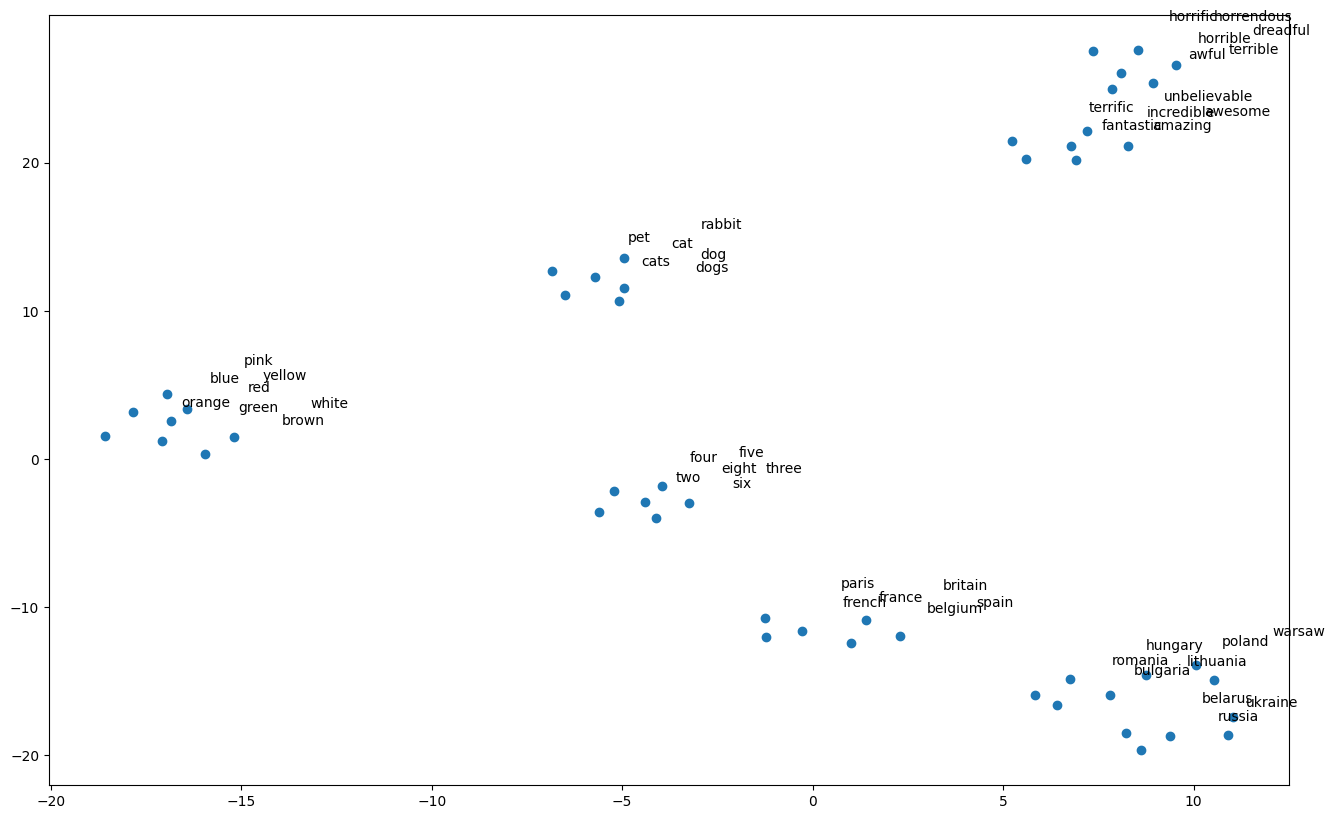

In [32]:
plot_word_embeddings(glove, ["awesome", "terrible", "ukraine", "poland", "france", "red", "green", "cat", "two"])

# Векторна аріфметика

Ми можемо додавати та віднімати вектори слів. Результат таких операцій (який теж буде вектором) можна перетворити назад в слово. Для цього знайдемо кілька найближчих до результата векторів і подивимося, які слова їм відповідають.

Векторну аріфметику використовують для пошуку слів за аналогіями. Класичний приклад з першої статті про Word2Vec виглядає так:

```
V("king") - V("man") + V("woman") ~= V("queen")
```

In [58]:
glove.similar_by_vector(glove["king"] - glove["man"] + glove["woman"])

[('king', 0.8209066987037659),
 ('queen', 0.7119165658950806),
 ('princess', 0.6121214628219604),
 ('monarch', 0.6024806499481201),
 ('prince', 0.596004068851471),
 ('throne', 0.5915313363075256),
 ('daughter', 0.5588055849075317),
 ('elizabeth', 0.554740309715271),
 ('kingdom', 0.5494517087936401),
 ('mother', 0.5419816970825195)]

### Завдання

Знайдіть найближчий вектор виразу
`paris` - `france` + `ukraine`

In [59]:
answer = glove.similar_by_vector(glove["paris"] - glove["france"] + glove["ukraine"])
lab.answer(answer)   # мені теж не подобається те, як написана відповідь :)

Відповідь правильна ✅
Так, вірно! 💪


[('kiev', 0.7856265306472778),
 ('ukraine', 0.7307591438293457),
 ('moscow', 0.6962895393371582),
 ('ukrainian', 0.6085987091064453),
 ('baku', 0.567898690700531),
 ('russia', 0.5644105076789856),
 ('helsinki', 0.5639599561691284),
 ('tbilisi', 0.561897873878479),
 ('minsk', 0.5441251993179321),
 ('yushchenko', 0.5439420342445374)]

In [60]:
#cвоя реалізація

all_words = glove.index_to_key
W = glove.vectors.astype(np.float32)

# Normalize each row to unit length
W_norm = W / np.linalg.norm(W, axis=1, keepdims=True)

def find_similar_fast_by_vector(vector: np.ndarray, top_n: int = 10) -> List[Tuple[float, str]]:
    """Return the `top_n` nearest neighbors of vector (fast vectorized version)."""
    v = normalize(vector)

    # Cosine similarity with all words (since both are normalized)
    sims = W_norm @ v

    # Get indices of the top_n highest similarities
    top_idx = np.argsort(-sims)[:top_n]

    return [(all_words[i], float(sims[i])) for i in top_idx]


In [61]:
target_vector = glove["paris"] - glove["france"] + glove["ukraine"]
answer = find_similar_fast_by_vector(target_vector)
lab.answer(answer)   # мені теж не подобається те, як написана відповідь :)

Відповідь правильна ✅
Так, вірно! 💪


[('kiev', 0.7856265902519226),
 ('ukraine', 0.7307592034339905),
 ('moscow', 0.696289598941803),
 ('ukrainian', 0.6085987091064453),
 ('baku', 0.5678987503051758),
 ('russia', 0.5644105672836304),
 ('helsinki', 0.5639599561691284),
 ('tbilisi', 0.5618978142738342),
 ('minsk', 0.5441251993179321),
 ('yushchenko', 0.5439419746398926)]

# Готово!

На наступному занятті ми:
- Використаємо ембедінги слів для класифікації текстів
- Дізнаємося, як влаштований word2vec
- Напишемо свою імплементацію word2vec
- Подивимося, як обійти проблему несловникових токенів
